# Wealth Manager Copilot - Evaluation & Analytics

This notebook evaluates the performance of the Wealth Manager Copilot on key metrics:
- Retrieval relevance and coverage
- Suitability gate precision
- Recommendation faithfulness/groundedness
- Agent performance on golden set queries

## 1. Import Libraries and Setup

In [1]:
import sys
sys.path.insert(0, '../')

import os
from dotenv import load_dotenv

# Load the project root environment first so OpenAI embeddings can authenticate
load_dotenv('../.env')

import json
import pandas as pd
import numpy as np
from datetime import datetime
import logging

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Agent and models
from src.agent import create_langgraph_agent
from src.retriever import RAGRetriever
from src.ingestion import KnowledgeIngestionPipeline
from src.tools import create_tools_dict
from config import settings

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print(f"Libraries loaded. API key present: {bool(os.environ.get('OPENAI_API_KEY'))}")

Libraries loaded. API key present: True


## 2. Setup Knowledge Base

In [2]:
# Initialize retriever against the project-level knowledge base
retriever = RAGRetriever(
    embedding_model="text-embedding-3-small",
    vector_store_type="faiss",
    persist_dir="../data/vector_store",
    openai_api_key=settings.openai_api_key
)

# Load or create knowledge base from the actual project uploads
retriever.load_existing_store()
stats = retriever.get_stats()

if stats.get('total_documents', 0) == 0:
    print("No documents found in ../data/user_uploads. Ingesting actual project knowledge...")
    pipeline = KnowledgeIngestionPipeline()
    docs = pipeline.run_ingestion_pipeline("../data/user_uploads")
    retriever.index_documents(docs, recreate=True)
    stats = retriever.get_stats()

print(f"Knowledge base ready! Stats: {stats}")

INFO:src.retriever:Initialized RAG Retriever (model: text-embedding-3-small, store: faiss)
INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
INFO:faiss.loader:Loading faiss.
INFO:faiss.loader:Successfully loaded faiss.
INFO:src.retriever:Loaded existing faiss vector store


Knowledge base ready! Stats: {'vector_store_type': 'faiss', 'total_documents': 816, 'persist_directory': '../data/vector_store'}


## 3. Test Queries (Golden Set)

In [3]:
# Define golden set test queries
golden_set_queries = [
    {
        "query_id": "GQ-001",
        "client_id": "C-204",
        "request": "Prepare talking points for client C-204's quarterly review",
        "expected_outcome": "grounded ClientBrief with portfolio summary and recommendations"
    },
    {
        "query_id": "GQ-002",
        "client_id": "C-202",
        "request": "Is fund XYZ suitable for a conservative client?",
        "expected_outcome": "suitability check with compliance assessment"
    },
    {
        "query_id": "GQ-003",
        "client_id": "C-204",
        "request": "Summarize the portfolio risk for client C-204",
        "expected_outcome": "portfolio summary with risk analysis"
    },
    {
        "query_id": "GQ-004",
        "client_id": "C-201",
        "request": "What recommendations would you make for client C-201?",
        "expected_outcome": "personalized recommendations with citations"
    },
]

print(f"Golden set has {len(golden_set_queries)} test queries")
for q in golden_set_queries:
    print(f"  - {q['query_id']}: {q['request'][:60]}...")

Golden set has 4 test queries
  - GQ-001: Prepare talking points for client C-204's quarterly review...
  - GQ-002: Is fund XYZ suitable for a conservative client?...
  - GQ-003: Summarize the portfolio risk for client C-204...
  - GQ-004: What recommendations would you make for client C-201?...


## 4. Retrieval Evaluation

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'conservative investor suitability...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'portfolio risk assessment...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'equity allocation recommendations...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'compliance checks...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'market research and outlook...' returned 3 results



Retrieval Performance:
                               query  num_results  top_score  avg_score  \
0  conservative investor suitability            3   0.879988   0.860491   
1          portfolio risk assessment            3   0.896163   0.892034   
2  equity allocation recommendations            3   0.875503   0.866796   
3                  compliance checks            3   0.998985   0.996079   
4        market research and outlook            3   1.084526   1.071122   

                       doc_types  
0     [product, product, policy]  
1    [product, product, product]  
2       [policy, policy, policy]  
3  [research, research, product]  
4     [policy, product, product]  


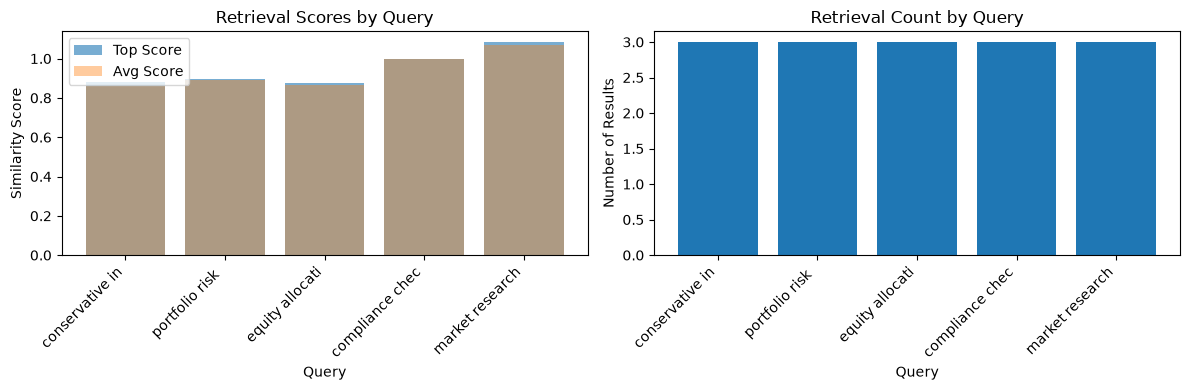


Retrieval Coverage: 15 total documents retrieved
Average Relevance Score: 0.937


In [10]:
# Test retrieval quality
retrieval_results = []

test_queries = [
    "conservative investor suitability",
    "portfolio risk assessment",
    "equity allocation recommendations",
    "compliance checks",
    "market research and outlook"
]

for query in test_queries:
    docs = retriever.hybrid_retrieve(query, k=3)
    
    retrieval_results.append({
        "query": query,
        "num_results": len(docs),
        "top_score": docs[0]["score"] if docs else 0,
        "avg_score": np.mean([d["score"] for d in docs]) if docs else 0,
        "doc_types": [d["metadata"].get("doc_type", "unknown") for d in docs]
    })

retrieval_df = pd.DataFrame(retrieval_results)
print("\nRetrieval Performance:")
print(retrieval_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
axes[0].bar(range(len(retrieval_df)), retrieval_df['top_score'], alpha=0.6, label='Top Score')
axes[0].bar(range(len(retrieval_df)), retrieval_df['avg_score'], alpha=0.4, label='Avg Score')
axes[0].set_xlabel('Query')
axes[0].set_ylabel('Similarity Score')
axes[0].set_title('Retrieval Scores by Query')
axes[0].legend()
axes[0].set_xticks(range(len(retrieval_df)))
axes[0].set_xticklabels([q[:15] for q in retrieval_df['query']], rotation=45, ha='right')

# Results count
axes[1].bar(range(len(retrieval_df)), retrieval_df['num_results'])
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Number of Results')
axes[1].set_title('Retrieval Count by Query')
axes[1].set_xticks(range(len(retrieval_df)))
axes[1].set_xticklabels([q[:15] for q in retrieval_df['query']], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nRetrieval Coverage: {retrieval_df['num_results'].sum()} total documents retrieved")
print(f"Average Relevance Score: {retrieval_df['avg_score'].mean():.3f}")

## 5. Suitability Gate Evaluation

In [11]:
from src.tools import SuitabilityCheckerTool

# Test suitability checker using the knowledge-base-grounded retriever
suitability_tool = SuitabilityCheckerTool(retriever=retriever)

test_cases = [
    {
        "risk_profile": "Conservative",
        "recommendation": {"idea": "Increase equity allocation", "product_type": "emerging_markets"},
        "expected_suitable": False
    },
    {
        "risk_profile": "Balanced",
        "recommendation": {"idea": "Diversified equity fund", "product_type": "large_cap_equity"},
        "expected_suitable": True
    },
    {
        "risk_profile": "Aggressive",
        "recommendation": {"idea": "Tech sector overweight", "product_type": "technology_fund"},
        "expected_suitable": True
    },
]

suitability_results = []

for i, test in enumerate(test_cases, 1):
    result = suitability_tool(
        test["risk_profile"],
        test["recommendation"]
    )
    
    is_correct = result["suitable"] == test["expected_suitable"]
    
    suitability_results.append({
        "test_case": i,
        "risk_profile": test["risk_profile"],
        "recommendation": test["recommendation"]["idea"][:30],
        "predicted_suitable": result["suitable"],
        "expected_suitable": test["expected_suitable"],
        "correct": is_correct,
        "violations": len(result.get("violations", [])),
        "policy_citations": len(result.get("policy_citations", []))
    })

suitability_df = pd.DataFrame(suitability_results)
print("\nSuitability Gate Evaluation:")
print(suitability_df)

accuracy = suitability_df["correct"].sum() / len(suitability_df) * 100
print(f"\nSuitability Gate Precision: {accuracy:.1f}%")
print(f"Total violations detected: {suitability_df['violations'].sum()}")
print(f"Total policy citations retrieved: {suitability_df['policy_citations'].sum()}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability rules for Conservative investors...' returned 2 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'restricted products emerging_markets compliance po...' returned 2 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'client risk profiling methodology Conservative...' returned 2 results
INFO:src.tools:Suitability KB grounding: 6 policy docs retrieved
INFO:src.tools:Suitability check - Conservative: PASSED
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability rules for Balanced investors...' returned 2 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.


Suitability Gate Evaluation:
   test_case  risk_profile              recommendation  predicted_suitable  \
0          1  Conservative  Increase equity allocation                True   
1          2      Balanced     Diversified equity fund                True   
2          3    Aggressive      Tech sector overweight                True   

   expected_suitable  correct  violations  policy_citations  
0              False    False           0                 6  
1               True     True           0                 6  
2               True     True           0                 6  

Suitability Gate Precision: 66.7%
Total violations detected: 0
Total policy citations retrieved: 18


## 6. Agent Performance on Golden Set

In [4]:
# Initialize agent with OpenAI API key for grounded synthesis
from config import settings

agent = create_langgraph_agent(
    llm_model="gpt-4o",
    retriever=retriever,
    openai_api_key=settings.openai_api_key,
    max_steps=100  # Increased from 20 to accommodate multiple KB queries per suitability check
)

print("Agent initialized with LLM-grounded synthesis.")
print("Retrieved documents will be passed to the LLM for generating grounded recommendations.\n")

agent_results = []

for query in golden_set_queries:
    try:
        print(f"Running {query['query_id']}: {query['request'][:50]}...")
        
        brief = agent.run_agent(
            client_id=query['client_id'],
            request=query['request']
        )
        
        agent_results.append({
            "query_id": query["query_id"],
            "status": "success",
            "client_id": brief.client_id,
            "num_recommendations": len(brief.recommendations),
            "num_talking_points": len(brief.talking_points),
            "compliance_status": brief.compliance_status.value,
            "escalated_items": len(brief.escalated_items),
            "citations_count": sum(len(r.citations) for r in brief.recommendations),
            "avg_confidence": np.mean([r.confidence_score for r in brief.recommendations]) if brief.recommendations else 0,
            "grounded_by_llm": brief.metadata.get("grounded_by_llm", False)
        })
        
        print(f"  ✓ Generated brief with {len(brief.recommendations)} recommendations")
        if brief.metadata.get("grounded_by_llm"):
            print(f"  ✓ LLM-grounded synthesis used retrieved documents\n")
        else:
            print(f"  ⚠ Non-grounded synthesis\n")
    
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}\n")
        agent_results.append({
            "query_id": query["query_id"],
            "status": "error",
            "error": str(e)[:100]
        })

agent_df = pd.DataFrame(agent_results)
print("\nAgent Performance Summary:")
print(agent_df)

INFO:src.agent:Initialized WealthManagerAgent (model: gpt-4o, max_steps: 100)
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-204, Request: Prepare talking points for client C-204's quarterly review
INFO:src.agent:[PLAN] Processing request: Prepare talking points for client C-204's quarterly review


Agent initialized with LLM-grounded synthesis.
Retrieved documents will be passed to the LLM for generating grounded recommendations.

Running GQ-001: Prepare talking points for client C-204's quarterl...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-204
INFO:src.tools:Portfolio lookup for C-204: 600000
INFO:src.agent:Portfolio fetched: $600,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'recommendations for Growth investors...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'Prepare talking points for client C-204's quarterl...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability and compliance checks...' returned 3 results
INFO:src.agent:Retrieved 9 research documents
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
INFO:httpx:HTT

  ✓ Generated brief with 3 recommendations
  ✓ LLM-grounded synthesis used retrieved documents

Running GQ-002: Is fund XYZ suitable for a conservative client?...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-202
INFO:src.tools:Portfolio lookup for C-202: 750000
INFO:src.agent:Portfolio fetched: $750,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'recommendations for Conservative investors...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'Is fund XYZ suitable for a conservative client?...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability and compliance checks...' returned 3 results
INFO:src.agent:Retrieved 9 research documents
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
INFO:httpx:

  ✓ Generated brief with 2 recommendations
  ✓ LLM-grounded synthesis used retrieved documents

Running GQ-003: Summarize the portfolio risk for client C-204...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-204
INFO:src.tools:Portfolio lookup for C-204: 600000
INFO:src.agent:Portfolio fetched: $600,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'recommendations for Growth investors...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'Summarize the portfolio risk for client C-204...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability and compliance checks...' returned 3 results
INFO:src.agent:Retrieved 9 research documents
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
INFO:httpx:HTTP Req

  ✓ Generated brief with 2 recommendations
  ✓ LLM-grounded synthesis used retrieved documents

Running GQ-004: What recommendations would you make for client C-2...


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-201
INFO:src.tools:Portfolio lookup for C-201: 500000
INFO:src.agent:Portfolio fetched: $500,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'recommendations for Balanced investors...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'What recommendations would you make for client C-2...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability and compliance checks...' returned 3 results
INFO:src.agent:Retrieved 9 research documents
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
INFO:httpx:H

  ✓ Generated brief with 3 recommendations
  ✓ LLM-grounded synthesis used retrieved documents


Agent Performance Summary:
  query_id   status client_id  num_recommendations  num_talking_points  \
0   GQ-001  success     C-204                    3                   3   
1   GQ-002  success     C-202                    2                   2   
2   GQ-003  success     C-204                    2                   2   
3   GQ-004  success     C-201                    3                   3   

  compliance_status  escalated_items  citations_count  avg_confidence  \
0           Cleared                0                5        0.800000   
1           Cleared                0                4        0.875000   
2           Cleared                0                3        0.800000   
3           Cleared                0                5        0.833333   

   grounded_by_llm  
0             True  
1             True  
2             True  
3             True  


## 6a. Grounding Analysis - Show Retrieved Documents Used in LLM

This section demonstrates that the LLM is using the retrieved documents to ground its recommendations.


In [5]:
# Show grounding analysis: Retrieved docs vs LLM recommendations
if agent_results and agent_results[0]["status"] == "success":
    # Get first successful query
    first_query = golden_set_queries[0]
    
    print("=" * 80)
    print(f"GROUNDING ANALYSIS: {first_query['query_id']}")
    print("=" * 80)
    print(f"\nRequest: {first_query['request']}")
    
    # Show what was retrieved
    print("\n--- RETRIEVED DOCUMENTS (passed to LLM for grounding) ---")
    retrieval_docs = retriever.hybrid_retrieve(first_query['request'], k=3)
    for idx, doc in enumerate(retrieval_docs):
        print(f"\n[DOC-{idx}] {doc['metadata'].get('source', 'unknown')}")
        print(f"  Type: {doc['metadata'].get('doc_type', 'unknown')}")
        print(f"  Score: {doc['score']:.4f}")
        print(f"  Content: {doc['content'][:300]}...")
    
    # Get the actual brief generated
    brief = agent.run_agent(
        client_id=first_query['client_id'],
        request=first_query['request']
    )
    
    # Show recommendations with citations
    print("\n--- LLM-GENERATED RECOMMENDATIONS (grounded in retrieved docs) ---")
    for i, rec in enumerate(brief.recommendations, 1):
        print(f"\n{i}. {rec.idea}")
        print(f"   Rationale: {rec.rationale}")
        print(f"   Confidence: {rec.confidence_score:.2%}")
        
        if rec.citations:
            print(f"   Citations ({len(rec.citations)}):")
            for citation in rec.citations:
                print(f"     - {citation.doc_id}: {citation.source}")
                print(f"       {citation.chunk_text[:150]}...")
        else:
            print(f"   Citations: None (generated without document grounding)")
    
    print("\n" + "=" * 80)
    print(f"✓ LLM used retrieved documents to ground {len(brief.recommendations)} recommendations")
    print("=" * 80)


GROUNDING ANALYSIS: GQ-001

Request: Prepare talking points for client C-204's quarterly review

--- RETRIEVED DOCUMENTS (passed to LLM for grounding) ---


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'Prepare talking points for client C-204's quarterl...' returned 3 results
INFO:src.agent:=== Starting Agent Run ===
INFO:src.agent:Client: C-204, Request: Prepare talking points for client C-204's quarterly review
INFO:src.agent:[PLAN] Processing request: Prepare talking points for client C-204's quarterly review



[DOC-0] data\user_uploads\RN-001_Q2_2026_Market_Outlook.pdf
  Type: product
  Score: 1.0435
  Content: recommendation for any specific client without a completed suitability check.
19. Comparison to Prior Quarter Outlook
RMs referencing this note alongside the firm's prior quarterly outlook publication should note the
following key changes in the desk's positioning stance. The desk's overall risk pos...

[DOC-1] data\user_uploads\RN-003_Fixed_Income_Outlook.docx
  Type: product
  Score: 1.0336
  Content: 15. RM Action Checklist for Fixed Income Client Conversations

To support consistent application of this research note's findings in client conversations, the desk provides the following structured checklist for RMs preparing a fixed income-focused client discussion.

Confirm the client's current ri...

[DOC-2] data\user_uploads\RN-002_Sector_Deep_Dive_Tech_AI.txt
  Type: policy
  Score: 1.0203
  Content: =============================================================
17. APPENDIX: RM P

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:src.agent:[GATHER_PORTFOLIO] Fetching for C-204
INFO:src.tools:Portfolio lookup for C-204: 600000
INFO:src.agent:Portfolio fetched: $600,000
INFO:src.agent:[GATHER_RESEARCH] Retrieving documents
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'recommendations for Growth investors...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'Prepare talking points for client C-204's quarterl...' returned 3 results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:src.retriever:Hybrid retrieval for query 'suitability and compliance checks...' returned 3 results
INFO:src.agent:Retrieved 9 research documents
INFO:src.agent:[CHECK_SUITABILITY] Validating recommendations
INFO:httpx:HTT


--- LLM-GENERATED RECOMMENDATIONS (grounded in retrieved docs) ---

1. Consider increasing exposure to the technology sector, with a focus on diversified exposure across AI-related cohorts.
   Rationale: Clients with a Growth profile may benefit from increased sector-tilted exposure, particularly in technology and AI, while ensuring diversification across cohorts to mitigate risk.
   Confidence: 85.00%
   Citations (1):
     - DOC-0: data\user_uploads\RN-002_Sector_Deep_Dive_Tech_AI.txt
       - Clients with a Growth or Aggressive profile and appropriate time
  horizon may consider increased sector-tilted exposure, subject to
  standard conc...

2. Evaluate the inclusion of an Aggressive Equity Fund to capitalize on potential outperformance during growth equity bull markets.
   Rationale: The Aggressive Equity Fund has historically outperformed during strong growth equity periods due to its high-conviction, concentrated structure, which aligns with the client's Growth risk profile.
  

## 7. Recommendation Groundedness Analysis


Recommendation Groundedness Metrics:
  query_id  recommendations  total_citations  avg_citations_per_rec  \
0   GQ-001                3                5               1.666667   
1   GQ-002                2                4               2.000000   
2   GQ-003                2                3               1.500000   
3   GQ-004                3                5               1.666667   

   avg_confidence  compliance_cleared  
0        0.800000                True  
1        0.875000                True  
2        0.800000                True  
3        0.833333                True  


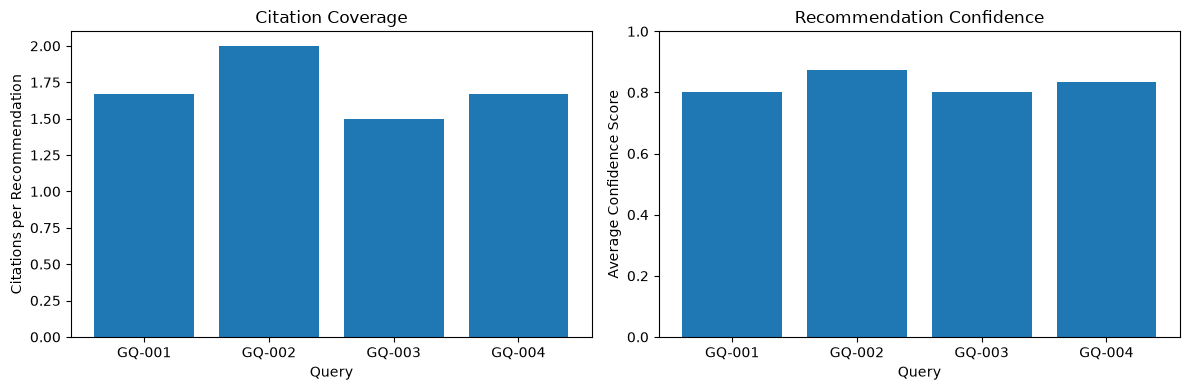


Average Citations per Recommendation: 1.71
Average Confidence Score: 0.827
Compliance Pass Rate: 100.0%


In [6]:
# Analyze groundedness and citation coverage
groundedness_metrics = []

for result in agent_results:
    if result["status"] == "success":
        groundedness_metrics.append({
            "query_id": result["query_id"],
            "recommendations": result["num_recommendations"],
            "total_citations": result["citations_count"],
            "avg_citations_per_rec": result["citations_count"] / max(result["num_recommendations"], 1),
            "avg_confidence": result["avg_confidence"],
            "compliance_cleared": result["compliance_status"] == "Cleared"
        })

groundedness_df = pd.DataFrame(groundedness_metrics)

print("\nRecommendation Groundedness Metrics:")
print(groundedness_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Citations per recommendation
axes[0].bar(range(len(groundedness_df)), groundedness_df['avg_citations_per_rec'])
axes[0].set_xlabel('Query')
axes[0].set_ylabel('Citations per Recommendation')
axes[0].set_title('Citation Coverage')
axes[0].set_xticks(range(len(groundedness_df)))
axes[0].set_xticklabels(groundedness_df['query_id'])

# Confidence scores
axes[1].bar(range(len(groundedness_df)), groundedness_df['avg_confidence'])
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Average Confidence Score')
axes[1].set_title('Recommendation Confidence')
axes[1].set_xticks(range(len(groundedness_df)))
axes[1].set_xticklabels(groundedness_df['query_id'])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nAverage Citations per Recommendation: {groundedness_df['avg_citations_per_rec'].mean():.2f}")
print(f"Average Confidence Score: {groundedness_df['avg_confidence'].mean():.3f}")
print(f"Compliance Pass Rate: {groundedness_df['compliance_cleared'].sum() / len(groundedness_df) * 100:.1f}%")

## 8. Comparative Analysis: Single-hop vs Multi-hop Retrieval

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"



Single-hop vs Multi-hop Retrieval Comparison:
                                               query  single_hop_count  \
0  What is the best allocation for a growth inves...                 5   
1  How should I balance emerging markets allocati...                 5   
2  What compliance issues arise with sector-speci...                 5   

   single_hop_score  multi_hop_count  multi_hop_score  
0          0.762407                6         0.790420  
1          0.830174                6         0.782256  
2          0.919301                6         0.913212  


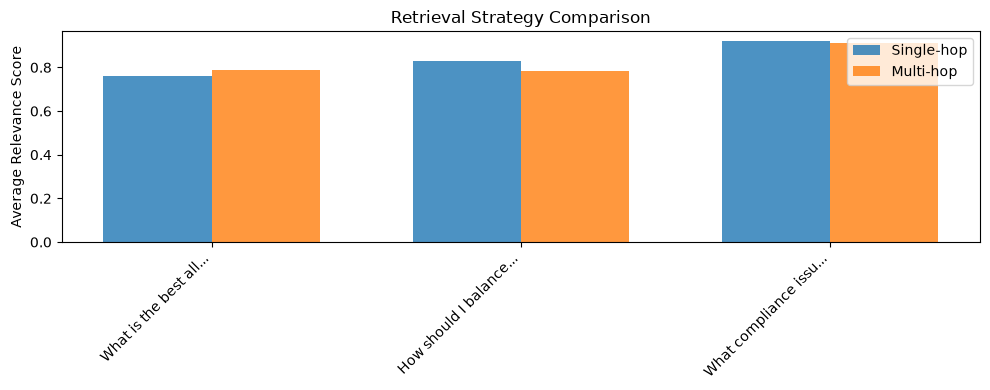

In [7]:
# Test single-hop vs multi-hop retrieval strategies
complex_queries = [
    "What is the best allocation for a growth investor with concentrated tech exposure?",
    "How should I balance emerging markets allocation for a conservative client?",
    "What compliance issues arise with sector-specific investment recommendations?"
]

comparison_results = []

for query in complex_queries:
    # Single hop (direct retrieval)
    single_hop_docs = retriever.retrieve_by_similarity(query, k=5)
    
    # Multi-hop approximation (multiple queries)
    related_queries = [
        query.split("?")[0],  # First part
        " ".join(query.split()[-5:]),  # Last few words
    ]
    
    multi_hop_docs = []
    for q in related_queries:
        multi_hop_docs.extend(retriever.retrieve_by_similarity(q, k=3))
    
    comparison_results.append({
        "query": query[:50],
        "single_hop_count": len(single_hop_docs),
        "single_hop_score": np.mean([doc[1] for doc in single_hop_docs]) if single_hop_docs else 0,
        "multi_hop_count": len(multi_hop_docs),
        "multi_hop_score": np.mean([doc[1] for doc in multi_hop_docs]) if multi_hop_docs else 0,
    })

comparison_df = pd.DataFrame(comparison_results)
print("\nSingle-hop vs Multi-hop Retrieval Comparison:")
print(comparison_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['single_hop_score'], width, label='Single-hop', alpha=0.8)
ax.bar(x + width/2, comparison_df['multi_hop_score'], width, label='Multi-hop', alpha=0.8)

ax.set_ylabel('Average Relevance Score')
ax.set_title('Retrieval Strategy Comparison')
ax.set_xticks(x)
ax.set_xticklabels([q[:20] + '...' for q in comparison_df['query']], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary and Key Metrics

In [12]:
# Generate comprehensive summary
summary = {
    "Retrieval Metrics": {
        "Total Documents Indexed": stats.get('total_documents', 0),
        "Average Retrieval Score": f"{retrieval_df['avg_score'].mean():.3f}",
        "Total Documents Retrieved": f"{retrieval_df['num_results'].sum()}",
        "Average Results per Query": f"{retrieval_df['num_results'].mean():.1f}"
    },
    "Suitability Gate Metrics": {
        "Precision": f"{accuracy:.1f}%",
        "Total Violations Detected": f"{suitability_df['violations'].sum()}",
    },
    "Agent Performance": {
        "Successful Queries": f"{(agent_df['status'] == 'success').sum()}/{len(agent_df)}",
        "Average Recommendations": f"{agent_df[agent_df['status'] == 'success']['num_recommendations'].mean():.1f}",
        "Total Citations Generated": f"{agent_df[agent_df['status'] == 'success']['citations_count'].sum()}",
    },
    "Recommendation Groundedness": {
        "Average Citations per Recommendation": f"{groundedness_df['avg_citations_per_rec'].mean():.2f}",
        "Average Confidence Score": f"{groundedness_df['avg_confidence'].mean():.3f}",
        "Compliance Pass Rate": f"{groundedness_df['compliance_cleared'].sum() / len(groundedness_df) * 100:.1f}%"
    }
}

print("\n" + "="*60)
print("WEALTH MANAGER COPILOT - EVALUATION SUMMARY")
print("="*60)

for category, metrics in summary.items():
    print(f"\n{category}:")
    for metric, value in metrics.items():
        print(f"  • {metric}: {value}")

print("\n" + "="*60)


WEALTH MANAGER COPILOT - EVALUATION SUMMARY

Retrieval Metrics:
  • Total Documents Indexed: 816
  • Average Retrieval Score: 0.937
  • Total Documents Retrieved: 15
  • Average Results per Query: 3.0

Suitability Gate Metrics:
  • Precision: 66.7%
  • Total Violations Detected: 0

Agent Performance:
  • Successful Queries: 4/4
  • Average Recommendations: 2.5
  • Total Citations Generated: 17

Recommendation Groundedness:
  • Average Citations per Recommendation: 1.71
  • Average Confidence Score: 0.827
  • Compliance Pass Rate: 100.0%



## 10. Export Results

In [13]:
# Export evaluation results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"./evaluation_results/{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# Save DataFrames
retrieval_df.to_csv(f"{output_dir}/retrieval_results.csv", index=False)
suitability_df.to_csv(f"{output_dir}/suitability_results.csv", index=False)
agent_df.to_csv(f"{output_dir}/agent_results.csv", index=False)
groundedness_df.to_csv(f"{output_dir}/groundedness_results.csv", index=False)

# Save summary as JSON
with open(f"{output_dir}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Evaluation results exported to: {output_dir}")
print(f"\nFiles saved:")
print(f"  - retrieval_results.csv")
print(f"  - suitability_results.csv")
print(f"  - agent_results.csv")
print(f"  - groundedness_results.csv")
print(f"  - summary.json")

Evaluation results exported to: ./evaluation_results/20260623_124857

Files saved:
  - retrieval_results.csv
  - suitability_results.csv
  - agent_results.csv
  - groundedness_results.csv
  - summary.json
